In [3]:
!pip install --upgrade protobuf tensorflow-metadata

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow # Special OpenCV display for Colab

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Version: 2.20.0
GPU Available: False


In [3]:
import os
import tensorflow as tf
from google.colab import files

# 1. Upload Kaggle Credentials
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# 2. Setup Kaggle API safely
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download and Unzip the Dataset
print("Downloading PlantVillage from Kaggle...")
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
print("Extracting files...")
!unzip -q plantvillage-dataset.zip -d plant_village_data

# The dataset extracts into a 'color' folder containing all 38 classes
DATA_DIR = 'plant_village_data/plantvillage dataset/color'

# 4. Preprocessing Constants
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# 5. Load Training Data (80%)
print("\nLoading Training Data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123, # Seed ensures no overlap between train/val
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# 6. Load Validation Data (20%)
print("\nLoading Validation Data...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# 7. Extract Class Names and Optimize
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"\nTotal Classes: {NUM_CLASSES}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
print("Dataset ready for training!")

Please upload your kaggle.json file:


Saving plant-disease-classification.ipynb to plant-disease-classification.ipynb
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:21<00:00, 101MB/s]

Extracting files...

Loading Training Data...
Found 54305 files belonging to 38 classes.
Using 43444 files for training.

Loading Validation Data...
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.

Total Classes: 38
Dataset ready for training!


In [4]:
# 1. Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

# 2. Base Model (MobileNetV2)
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze pre-trained weights

# 3. Build Final Architecture
inputs = tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# 4. Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
import tensorflow as tf

print("Reloading dataset into memory...")
DATA_DIR = 'plant_village_data/plantvillage dataset/color'
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Re-create train_dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Re-create validation_dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Optimize for speed
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset successfully reloaded! You can now run the training cell.")


Reloading dataset into memory...
Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Dataset successfully reloaded! You can now run the training cell.


Successfully loaded 38 classes for prediction.

Please upload a leaf image (.jpg, .png) for testing:


Saving download.jpg to download.jpg

PREDICTION: Corn_(maize)___Northern_Leaf_Blight
CONFIDENCE: 9.49%



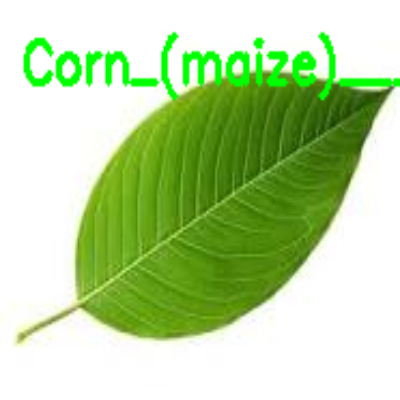

In [8]:
# --- 1. ALWAYS IMPORT LIBRARIES FIRST ---
import cv2
import numpy as np
import tensorflow as tf
import os
from google.colab import files
from google.colab.patches import cv2_imshow

# --- 2. EXTRACT CLASS NAMES DIRECTLY FROM FOLDERS ---
DATA_DIR = 'plant_village_data/plantvillage dataset/color'
try:
    # This reads the 38 folder names in alphabetical order, exactly how the model learned them
    class_names = sorted(os.listdir(DATA_DIR))
    print(f"Successfully loaded {len(class_names)} classes for prediction.")
except FileNotFoundError:
    print("Error: Dataset folders not found. Please ensure the Kaggle download cell was run!")

IMAGE_SIZE = (224, 224)

# --- 3. PREDICTION FUNCTION ---
def predict_uploaded_image(image_path):
    # Read and format image
    img = cv2.imread(image_path)
    if img is None:
        print("Error reading image.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMAGE_SIZE)
    img_batch = np.expand_dims(img_resized, axis=0)

    # Predict using the model
    predictions = model.predict(img_batch, verbose=0)
    class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100
    predicted_class = class_names[class_idx]

    # Print text results
    print("\n" + "="*40)
    print(f"PREDICTION: {predicted_class}")
    print(f"CONFIDENCE: {confidence:.2f}%")
    print("="*40 + "\n")

    # Display image with result using Colab's cv2_imshow
    cv2.putText(img, f"{predicted_class} ({confidence:.1f}%)", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Resize for display purposes so it doesn't take up the whole screen
    display_img = cv2.resize(img, (400, 400))
    cv2_imshow(display_img)

# --- 4. TRIGGER COLAB UPLOAD ---
print("\nPlease upload a leaf image (.jpg, .png) for testing:")
uploaded = files.upload()

for filename in uploaded.keys():
    predict_uploaded_image(filename)